In [32]:
from src.analysis import NoisyContingencyTable
from src.core import NoisyFloat
from src.core import sample_noisy_values
from src.noise import NormalNoiseSource

import src.io as io
import src.visual as visual

## Noisy numbers

Suppose we have two numbers `x` and `y`.

In [33]:
x = 8.0
y = 13.0

We can do arithmetic on them. Because we are certain about the values of the numbers, we are certain about the result of the arithmetic.

In [34]:
z = x + y
z

21.0

But suppose we aren't certain. Suppose we don't know that `x` is 8 and `y` is 13. Instead we have _observations_ of `x` and `y`, but we understand that those observations aren't quite right: there's some _noise_ involved. Suppose also we know that noise is drawn **separately** for `x` and `y` from a Normal distribution with $\mu = 0.0$ and $\sigma = 1.6$.

Then we can model `x` and `y` like this.

In [35]:
x = NoisyFloat.draw(true_value=8.0, noise_source=NormalNoiseSource(loc=0.0, scale=1.6))
y = NoisyFloat.draw(true_value=13.0, noise_source=NormalNoiseSource(loc=0.0, scale=1.6))

This is what `NoisyFloat` does: it pairs a noisy observation with our belief about what the true value actually is, in the form of a _posterior probability distribution_ - in this case, it's a Normal probability distribution centered on the measured value.

The observation part is stored inside the `NoisyFloat` as a floating point number. We can access it by converting the `NoisyFloat` to a `float` like this.

In [36]:
float(x)

8.256212319495104

In [37]:
float(y)

14.641931369971065

Notice the observations are not 8 and 13 anymore. In fact, 8 and 13 exist nowhere in `x` or `y` now, and they are not recoverable!

The posteriors are represented inside the `NoisyFloat` too, symbolically, in a way that is difficult to interact with manually. A good way for us to get a sense for the posterior is by plotting it. We can even plot the posteriors of `x` and `y` together.

{'ax': <Axes: title={'center': 'Posterior Densities of Composed Expressions'}, xlabel='Expression value', ylabel='Posterior density'>,
 'curves': [{'noisy_value': ~8.256212319495104,
   'x': array([ 3.6867981 ,  3.70511238,  3.72342667,  3.74174096,  3.76005524,
           3.77836953,  3.79668381,  3.8149981 ,  3.83331238,  3.85162667,
           3.86994095,  3.88825524,  3.90656952,  3.92488381,  3.9431981 ,
           3.96151238,  3.97982667,  3.99814095,  4.01645524,  4.03476952,
           4.05308381,  4.07139809,  4.08971238,  4.10802666,  4.12634095,
           4.14465524,  4.16296952,  4.18128381,  4.19959809,  4.21791238,
           4.23622666,  4.25454095,  4.27285523,  4.29116952,  4.3094838 ,
           4.32779809,  4.34611238,  4.36442666,  4.38274095,  4.40105523,
           4.41936952,  4.4376838 ,  4.45599809,  4.47431237,  4.49262666,
           4.51094094,  4.52925523,  4.54756952,  4.5658838 ,  4.58419809,
           4.60251237,  4.62082666,  4.63914094,  4.65745523, 

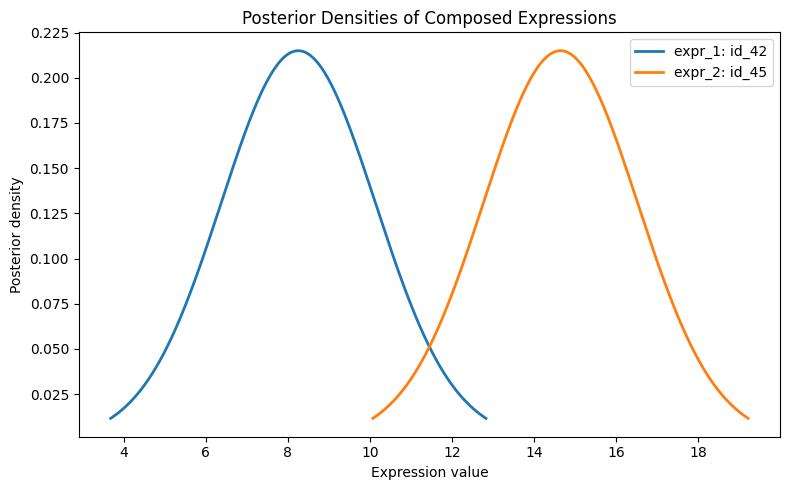

In [38]:
visual.plot_posterior(x, y)

What happens if we add `x` and `y` now?

In [39]:
z = x + y
z

~22.898143689466167

We get a new `NoisyFloat` whose _observation_ is the sum of the observations of `x` and `y` and whose posterior takes into account the posteriors of `x` and `y`. Notice when we plot all three together how `z` is expected to be higher than both `x` and `y` because it is their sum, but its tails are thicker. We can less certain about what `z` actually is because it _combines_ our uncertainty about `x` with our uncertainty about `y`.

{'ax': <Axes: title={'center': 'Posterior Densities of Composed Expressions'}, xlabel='Expression value', ylabel='Posterior density'>,
 'curves': [{'noisy_value': ~8.256212319495104,
   'x': array([ 3.6867981 ,  3.70511238,  3.72342667,  3.74174096,  3.76005524,
           3.77836953,  3.79668381,  3.8149981 ,  3.83331238,  3.85162667,
           3.86994095,  3.88825524,  3.90656952,  3.92488381,  3.9431981 ,
           3.96151238,  3.97982667,  3.99814095,  4.01645524,  4.03476952,
           4.05308381,  4.07139809,  4.08971238,  4.10802666,  4.12634095,
           4.14465524,  4.16296952,  4.18128381,  4.19959809,  4.21791238,
           4.23622666,  4.25454095,  4.27285523,  4.29116952,  4.3094838 ,
           4.32779809,  4.34611238,  4.36442666,  4.38274095,  4.40105523,
           4.41936952,  4.4376838 ,  4.45599809,  4.47431237,  4.49262666,
           4.51094094,  4.52925523,  4.54756952,  4.5658838 ,  4.58419809,
           4.60251237,  4.62082666,  4.63914094,  4.65745523, 

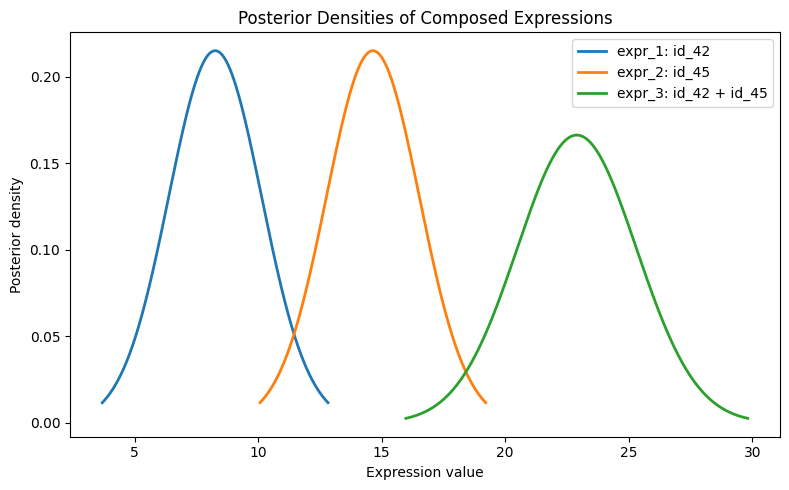

In [40]:
visual.plot_posterior(x, y, z)

Most common arithmetic operations are supported. In this way, the library pairs observations and posteriors together, and propagates them in tandem through arithmetic operations.

## Interpreting posteriors

The posterior tells the "whole story" about what we should believe about the true value associated with an observation, but standard metrics can be derived from it that are sometimes easier to work with. It all starts with sampling the posterior.

In [41]:
batch = z.sample(n=1000)

Now we have `batch` which is a `SampleBatch` object. `SampleBatch` just wraps a NumPy array, so we can always take `batch.draws` and do whatever we want with that.

There are some convenience methods on `batch` though. Most notably there is a way to get the _credible interval_ for `z`. A credible interval is similar to a confidence interval, but for Bayesian statistics.

In [42]:
batch.credible_interval(p=0.95)

array([18.52103347, 27.03658408])

As an aside... for the Normal distributions we've been working with, it's technically possible to get these metrics without sampling: there are nice analytic solutions. However since the library supports more than just simple Normal distributions, it opts for the more universal sampling approach.

## Noisy booleans

Suppose we want to _compare_ `x` and `y`. Maybe we're curious if `y` is really larger. If we notice how the plots of their posteriors that we created earlier have overlap, we will know there is a chance that the true value of `x` is actually larger than that of `y`, even though we have observations that (probably) suggest otherwise.

In [43]:
g = y > x
g

~True

The result of the comparison is `g`, a `NoisyBool`. `NoisyBool` is very similar to `NoisyFloat` in that it pairs a noisy observation - a `bool` in this case - with a posterior. In fact, both derive from `NoisyValue`, where you can also find `NoisyInt`.

Sampling the posterior gives Trues and Falses, which we can see if we look at the first few elements of the resulting sample batch.

In [44]:
batch = g.sample(n=1000)
batch.draws[:5]

array([ True,  True,  True,  True,  True])

We can sum the batch elements together and divide by the number of elements to get the probability that `y > x`.

(TODO) It probably makes sense to provide a more idiomatic way to do this soon.

In [45]:
sum(batch.draws) / len(batch.draws)

np.float64(0.998)

What about if we want to know the probability that `z` is between 22.0 and 26.0? We can use boolean connectives like `&`, `|`, and `not`.

In [46]:
g = (z >= 22.0) & (z <= 26.0)
g

~True

Notice how we're mixing regular numbers in with the the `NoisyFloat` object `z` here. This is usually okay because the library can _lift_ regular values into noisy values as needed. But we can also lift explicitly, creating noisy values with observations 22.0 or 26.0 and that have no added noise.

In [47]:
g = (z >= NoisyFloat.lift(22.0)) & (z <= NoisyFloat.lift(26.0))
g

~True

And exactly as before, we can sample the posterior of `g` to estimate the probability that `g` is True.

In [48]:
batch = g.sample(n=1000)
sum(batch.draws) / len(batch.draws)

np.float64(0.583)

## Contingency tables

With these building blocks, the library provides the `NoisyContingencyTable`. The elements can be noisy, or not. Regular values will automatically lift into noisy ones.

In [49]:
tbl = NoisyContingencyTable([[12, 55], [24, 9]])

You can get `chi_squared` out of it, and also `odds_ratio` if it's a 2x2 table. Both of these will be noisy values, so their posteriors will include any uncertainty from the original counts.

In [50]:
tbl.chi_squared()

~28.83593396653098

In [53]:
tbl.odds_ratio()

~0.08181818181818182

You can also get a copy of the table whose counts include uncertainty from stratified sampling. This sampling uncertainty gets composed with any uncertainty from the original counts (say they were differentially privatized or something).

So putting it all together, if you want the Bayesian version of the 95% odds ratio confidence interval you could do this.

In [ ]:
tbl.with_stratified_sampling_uncertainty().odds_ratio().credible_interval(p=0.95)

## Differential privacy

An API for creating differentially private data releases may be coming soon...

## Sharing noisy systems


Finally, the library can save _noisy containers_ to files, and reload them. The motivation for this feature is differentially private data releases. Maybe it has broader applications too. With differentially private data, you usually just get the noisy observations, and maybe a way to understand the distribution of the noise that was added to it. With noisy containers, you embed the noisy observations together with their true value posteriors into a single file in a way that preserves dependencies and correlations between them.

You can save a few different things.

1. A single `NoisyValue` (could be a `NoisyFloat`, `NoisyInt`, or `NoisyBool`)
2. A possibly multi-dimensional array of `NoisyValue`
3. A tuple whose elements can be a mix of the first two things

WARNING: This writes data to disk!

In [51]:
io.save("tmp.json", (x, y, z))

Then reload the file, capturing the container in something of the same shape.

In [52]:
x2, y2, z2 = io.load("tmp.json")

Note that while all the noise sources in `x2`, `y2`, and `z2` shared or not shared in exactly the same ways as  those in `x`, `y`, and `z`, there is no connection _between_ the noise sources of the two groups.